# RQ1: Which Cities Score Highest on Quality of Life Relative to Cost of Living?

**Research question:** Across all cities in the Numbeo dataset, which offer the highest quality of urban life per dollar of cost?

**Hypothesis:** The highest-value cities will not be the usual liveability top-10 (Vienna, Copenhagen, Zurich). Instead, they will be mid-sized cities in Eastern Europe, Southeast Asia, and Latin America, where public services are strong relative to the local cost base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import warnings
warnings.simplefilter('ignore')

YEAR = 2025

REGION_COLORS = {
    'Eastern Europe': '#3B82F6', 'Western Europe': '#6366F1',
    'North America': '#F59E0B', 'Latin America': '#10B981',
    'East Asia': '#EF4444', 'Southeast Asia': '#EC4899',
    'South Asia': '#8B5CF6', 'MENA': '#F97316',
    'Sub-Saharan Africa': '#6B7280', 'Oceania': '#14B8A6', 'Other': '#94A3B8',
}

REGION_MAP = {
    'Romania': 'Eastern Europe', 'Bulgaria': 'Eastern Europe', 'Hungary': 'Eastern Europe',
    'Czech Republic': 'Eastern Europe', 'Poland': 'Eastern Europe', 'Serbia': 'Eastern Europe',
    'Croatia': 'Eastern Europe', 'Slovakia': 'Eastern Europe', 'Slovenia': 'Eastern Europe',
    'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe', 'Russia': 'Eastern Europe',
    'Bosnia And Herzegovina': 'Eastern Europe', 'North Macedonia': 'Eastern Europe',
    'Albania': 'Eastern Europe', 'Moldova': 'Eastern Europe', 'Estonia': 'Eastern Europe',
    'Latvia': 'Eastern Europe', 'Lithuania': 'Eastern Europe', 'Montenegro': 'Eastern Europe',
    'Georgia': 'Eastern Europe', 'Armenia': 'Eastern Europe', 'Azerbaijan': 'Eastern Europe',
    'Kazakhstan': 'Eastern Europe', 'Kosovo (Disputed Territory)': 'Eastern Europe',
    'Germany': 'Western Europe', 'France': 'Western Europe', 'Spain': 'Western Europe',
    'Italy': 'Western Europe', 'Portugal': 'Western Europe', 'Netherlands': 'Western Europe',
    'Belgium': 'Western Europe', 'Switzerland': 'Western Europe', 'Austria': 'Western Europe',
    'Sweden': 'Western Europe', 'Norway': 'Western Europe', 'Denmark': 'Western Europe',
    'Finland': 'Western Europe', 'Ireland': 'Western Europe', 'Luxembourg': 'Western Europe',
    'Greece': 'Western Europe', 'Cyprus': 'Western Europe', 'Malta': 'Western Europe',
    'Iceland': 'Western Europe', 'United Kingdom': 'Western Europe',
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Colombia': 'Latin America',
    'Chile': 'Latin America', 'Peru': 'Latin America', 'Ecuador': 'Latin America',
    'Bolivia': 'Latin America', 'Uruguay': 'Latin America', 'Paraguay': 'Latin America',
    'Costa Rica': 'Latin America', 'Guatemala': 'Latin America',
    'Dominican Republic': 'Latin America', 'Venezuela': 'Latin America',
    'Jamaica': 'Latin America', 'Trinidad And Tobago': 'Latin America',
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Taiwan': 'East Asia',
    'Thailand': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Malaysia': 'Southeast Asia', 'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia',
    'Cambodia': 'Southeast Asia',
    'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
    'Nepal': 'South Asia', 'Sri Lanka': 'South Asia',
    'Israel': 'MENA', 'Turkey': 'MENA', 'Iran': 'MENA', 'Iraq': 'MENA',
    'Jordan': 'MENA', 'Lebanon': 'MENA', 'Saudi Arabia': 'MENA',
    'United Arab Emirates': 'MENA', 'Qatar': 'MENA', 'Kuwait': 'MENA',
    'Bahrain': 'MENA', 'Oman': 'MENA', 'Morocco': 'MENA', 'Egypt': 'MENA',
    'Algeria': 'MENA', 'Tunisia': 'MENA', 'Libya': 'MENA',
    'South Africa': 'Sub-Saharan Africa', 'Nigeria': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa',
    'Tanzania': 'Sub-Saharan Africa', 'Uganda': 'Sub-Saharan Africa',
    'Zimbabwe': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}


In [ ]:
def load_numbeo_sheet(filepath, year):
    return pd.read_excel(filepath, sheet_name=str(year))

cost      = load_numbeo_sheet('../data/raw/numbeo_cost_of_living_city.xlsx', YEAR)
safety    = load_numbeo_sheet('../data/raw/numbeo_crime.xlsx',               YEAR)
health    = load_numbeo_sheet('../data/raw/numbeo_health_care.xlsx',         YEAR)
pollution = load_numbeo_sheet('../data/raw/numbeo_pollution.xlsx',           YEAR)
traffic   = load_numbeo_sheet('../data/raw/numbeo_traffic.xlsx',             YEAR)

# Compute global traffic bounds across all years for consistent normalization
_traffic_all = pd.concat([
    pd.read_excel('../data/raw/numbeo_traffic.xlsx', sheet_name=s)
    for s in pd.ExcelFile('../data/raw/numbeo_traffic.xlsx').sheet_names
    if s.strip().isdigit()
])
TRAFFIC_GLOBAL_MIN = _traffic_all['Traffic Index'].min()
TRAFFIC_GLOBAL_MAX = _traffic_all['Traffic Index'].max()
print(f'Traffic Index global range: {TRAFFIC_GLOBAL_MIN:.1f} – {TRAFFIC_GLOBAL_MAX:.1f}')

df = (
    cost[['City', 'Cost of Living Index', 'Local Purchasing Power Index']]
    .merge(safety[['City', 'Safety Index']],       on='City')
    .merge(health[['City', 'Health Care Index']],  on='City')
    .merge(pollution[['City', 'Pollution Index']], on='City')
    .merge(traffic[['City', 'Traffic Index']],     on='City')
)

df['country']       = df['City'].str.split(',').str[-1].str.strip()
df['region']        = df['country'].map(REGION_MAP).fillna('Other')
df['pollution_inv'] = 100 - df['Pollution Index']
df['traffic_score'] = 100 * (1 - (df['Traffic Index'] - TRAFFIC_GLOBAL_MIN) /
                                    (TRAFFIC_GLOBAL_MAX - TRAFFIC_GLOBAL_MIN))
df['quality_score'] = df[['Safety Index', 'Health Care Index',
                            'pollution_inv', 'traffic_score']].mean(axis=1)
df['value_index']   = (df['quality_score'] / df['Cost of Living Index']).round(3)
df['size_bubble']   = df['value_index'].clip(lower=0)
df['affordability'] = (df['Local Purchasing Power Index'] / df['Cost of Living Index']).round(3)

print(f'Cities in {YEAR} with all sub-indices: {len(df)}')
print(df[['City', 'quality_score', 'Cost of Living Index', 'value_index']]
      .sort_values('value_index', ascending=False).head(10).to_string(index=False))


## Index Construction

**Composite quality score** = arithmetic mean of four dimensions:
- Safety Index (Numbeo)
- Health Care Index (Numbeo)
- 100 − Pollution Index (inverted: lower pollution = higher quality)
- 100 − Traffic Index (inverted: lower traffic congestion = higher quality)

All four sub-indices are on a 0–100 perception-based scale and are NOT anchored to NYC. They can be compared directly across cities and, for the same city, across years.

**Value index** = composite quality score ÷ Cost of Living Index

This keeps quality and cost analytically independent. We deliberately do **not** use Numbeo's own composite Quality of Life Index, which already incorporates cost of living into its formula, defeating the purpose of this analysis.

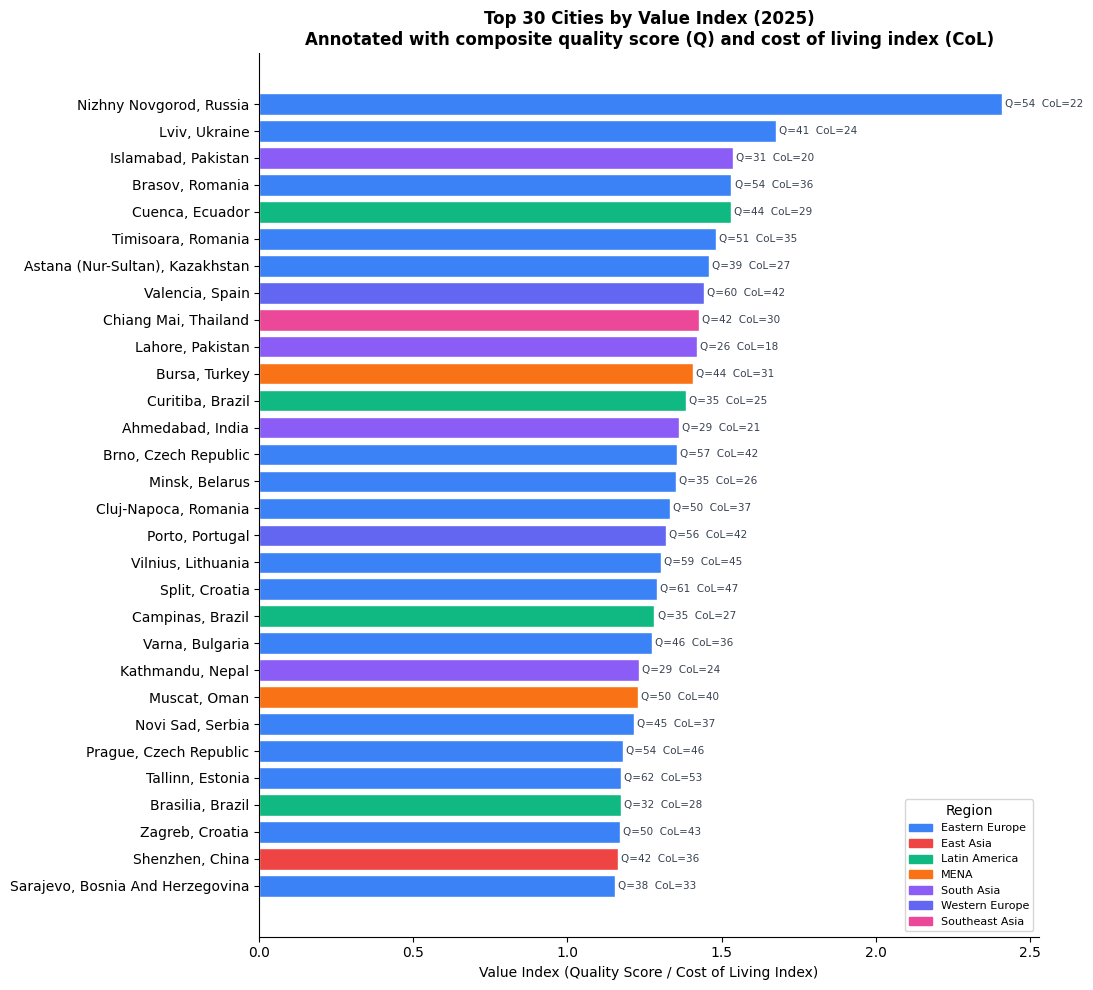

In [3]:
top30 = df.nlargest(30, 'value_index').sort_values('value_index')

colors = [REGION_COLORS.get(r, REGION_COLORS['Other']) for r in top30['region']]

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(top30['City'], top30['value_index'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, top30.iterrows()):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"Q={row['quality_score']:.0f}  CoL={row['Cost of Living Index']:.0f}",
            va='center', fontsize=7.5, color='#374151')

ax.set_title(f'Top 30 Cities by Value Index ({YEAR})\n'
             'Annotated with composite quality score (Q) and cost of living index (CoL)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Value Index (Quality Score / Cost of Living Index)')
ax.spines[['top', 'right']].set_visible(False)

seen = {}
for _, row in top30.iterrows():
    r = row['region']
    if r not in seen:
        seen[r] = REGION_COLORS.get(r, REGION_COLORS['Other'])
patches = [plt.Rectangle((0,0),1,1, color=c, label=r) for r,c in seen.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8, title='Region')

plt.tight_layout()
plt.show()


---
## Section 2: The Value Quadrant

The central visual of this project. Every city is plotted by its cost (x-axis) and quality (y-axis). Quadrant lines sit at the median cost and median quality across all cities:

- **Top-left (Sweet Spots):** High quality, low cost - the cities this project champions
- **Top-right (Prestigious):** High quality, high cost - the EIU/Mercer favourites
- **Bottom-left (Budget):** Low quality, low cost - cheap but limited
- **Bottom-right (Traps):** Low quality, high cost - worst of both worlds

Bubble size reflects the value index. Cities marked with * are well-known traditional liveability top cities (EIU).

In [4]:
med_cost    = df['Cost of Living Index'].median()
med_quality = df['quality_score'].median()

# Label the top 15 value cities + well-known traditional liveability cities
top15_cities  = set(df.nlargest(15, 'value_index')['City'])
flagship_names = ['Vienna', 'Copenhagen', 'Zurich', 'Melbourne', 'Tokyo']
flagship_cities = set()
for name in flagship_names:
    matches = df[df['City'].str.startswith(name)]['City'].tolist()
    flagship_cities.update(matches)

def label_city(row):
    if row['City'] in top15_cities:    return row['City'].split(',')[0]
    if row['City'] in flagship_cities: return row['City'].split(',')[0] + ' *'
    return ''

df['label']       = df.apply(label_city, axis=1)
df['size_bubble'] = df['value_index'].clip(lower=0)  # plotly requires non-negative sizes

fig = px.scatter(
    df,
    x='Cost of Living Index',
    y='quality_score',
    size='size_bubble',
    color='region',
    hover_name='City',
    text='label',
    color_discrete_map=REGION_COLORS,
    hover_data={
        'value_index': ':.3f',
        'quality_score': ':.1f',
        'Cost of Living Index': ':.1f',
        'size_bubble': False,
        'region': False,
    },
    title=f'Quality vs Cost of Living - The Value Quadrant ({YEAR})\n'
          '(* = traditional EIU top cities  |  bubble size = value index)',
    labels={
        'Cost of Living Index': 'Cost of Living Index (NYC = 100)',
        'quality_score':        'Composite Quality Score (0-100)',
        'region':               'Region',
    },
    size_max=20,
)

fig.add_vline(x=med_cost,    line_dash='dot', line_color='grey',
              annotation_text='Median cost', annotation_position='top right')
fig.add_hline(y=med_quality, line_dash='dot', line_color='grey',
              annotation_text='Median quality', annotation_position='right')

fig.update_traces(textposition='top center', textfont=dict(size=9))
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                  legend=dict(font=dict(size=9)),
                  annotations=[
                      dict(x=med_cost*0.5,  y=med_quality*1.15, text='Sweet Spots',
                           showarrow=False, font=dict(size=11, color='#10B981')),
                      dict(x=med_cost*1.5,  y=med_quality*1.15, text='Prestigious',
                           showarrow=False, font=dict(size=11, color='#6366F1')),
                      dict(x=med_cost*0.5,  y=med_quality*0.6,  text='Budget',
                           showarrow=False, font=dict(size=11, color='#94A3B8')),
                      dict(x=med_cost*1.5,  y=med_quality*0.6,  text='Traps',
                           showarrow=False, font=dict(size=11, color='#EF4444')),
                  ])
fig.show()


---
## Section 3: What Drives the Top Cities?

Are top-value cities safe? Do they have good healthcare? Or are they simply very cheap? The heatmap below shows each quality dimension for the top 30 value cities, revealing whether their scores are built on strength across all dimensions or driven by one standout factor.

In [ ]:
top30_hm = df.nlargest(30, 'value_index').sort_values('value_index', ascending=False)

dim_labels = {
    'Safety Index':     'Safety',
    'Health Care Index':'Healthcare',
    'pollution_inv':    'Clean Air',
    'traffic_score':    'Low Traffic',
}
hm_data = top30_hm[list(dim_labels)].rename(columns=dim_labels)
hm_data.index = top30_hm['City'].str.split(',').str[0].values

fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(
    hm_data, ax=ax,
    cmap='RdYlGn', vmin=0, vmax=100,
    annot=True, fmt='.0f', annot_kws={'size': 8},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Score (0-100)', 'shrink': 0.6}
)
ax.set_title(f'What Drives Each Top City? Quality Dimensions for Top 30 ({YEAR})\n'
             '(sorted by value index, highest at top)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Quality Dimension')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nDimension averages - Top 30 vs full dataset:')
for dim, lbl in dim_labels.items():
    t = top30_hm[dim].mean()
    a = df[dim].mean()
    print(f'  {lbl:15s}: top-30 avg={t:.1f}  all-city avg={a:.1f}  diff={t-a:+.1f}')


---
## Section 4: Geographic Distribution

The project predicts sweet spots cluster in middle-income countries - wealthy enough for decent infrastructure but not so expensive that costs outpace quality. The choropleth below shows the best city value index per country, making regional clustering visible at a glance.

In [6]:
# Country-level: best city value index per country
country_best = (
    df.groupby('country')['value_index'].max().reset_index()
    .rename(columns={'value_index': 'best_value_index'})
)

fig = px.choropleth(
    country_best,
    locations='country',
    locationmode='country names',
    color='best_value_index',
    color_continuous_scale='Teal',
    title=f'Geographic Distribution of Best City Value Index by Country ({YEAR})\n'
          'Color = highest value index city in that country',
    labels={'best_value_index': 'Best Value Index'},
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

print('\nTop 5 countries by their best city value index:')
print(country_best.nlargest(5, 'best_value_index').to_string(index=False))



Top 5 countries by their best city value index:
 country  best_value_index
  Russia             2.409
 Ukraine             1.677
Pakistan             1.538
 Romania             1.532
 Ecuador             1.531


---
## Section 5: Challenging Traditional Liveability Indices

Existing indices like the EIU Global Liveability ranking consistently place wealthy Western cities at the top - Vienna, Copenhagen, Zurich, Melbourne. Our central argument is that this reflects a wealthy-expat bias: these cities are undeniably high-quality, but they are also among the most expensive in the world.

Panel A shows where EIU top-10 cities rank on *our* value index. Panel B shows the cost of living for our own top-10 value cities. The contrast illustrates the affordability gap that existing indices ignore.

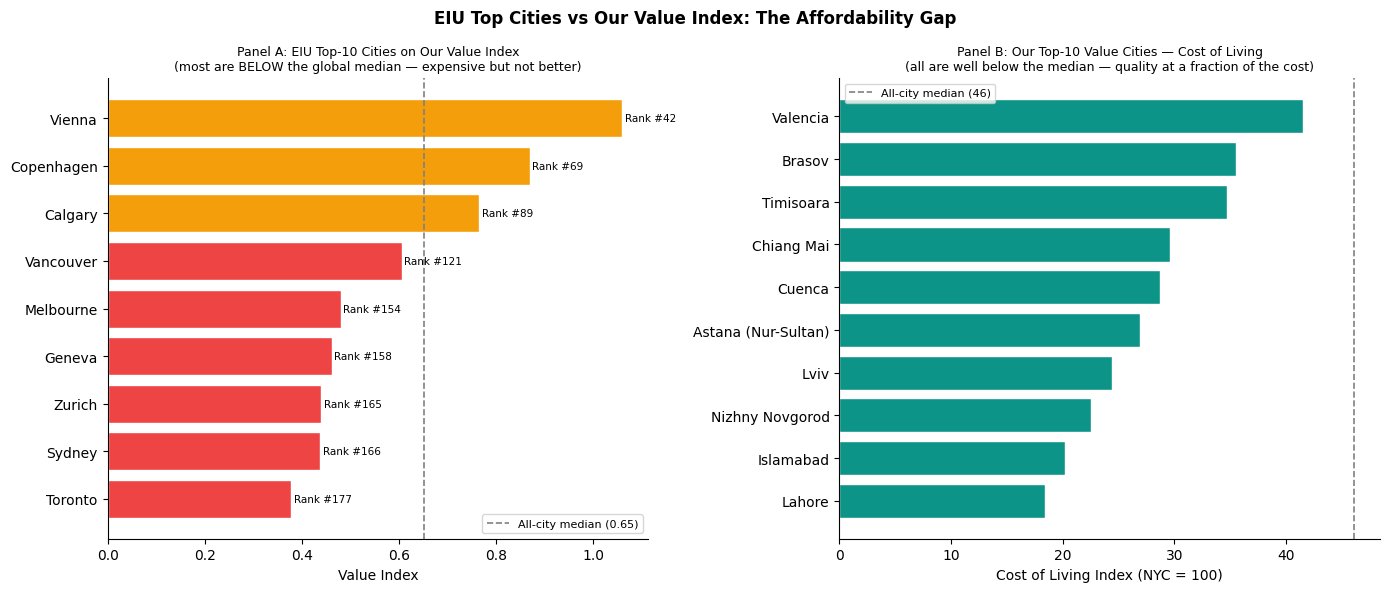


EIU top 10 cities on our value index:
  EIU City  value_index  Cost of Living Index  our_rank
    Vienna        1.060                  61.2        42
Copenhagen        0.869                  71.3        69
   Calgary        0.765                  61.0        89
 Vancouver        0.606                  62.7       121
 Melbourne        0.480                  60.9       154
    Geneva        0.461                 100.7       158
    Zurich        0.440                 103.8       165
    Sydney        0.438                  67.6       166
   Toronto        0.378                  61.4       177


In [7]:
# EIU Global Liveability top 10 (2023 ranking - public knowledge, hardcoded)
EIU_TOP10 = ['Vienna', 'Copenhagen', 'Melbourne', 'Sydney', 'Vancouver',
             'Zurich', 'Calgary', 'Geneva', 'Toronto', 'Osaka']

eiu_rows = []
for name in EIU_TOP10:
    matches = df[df['City'].str.startswith(name)]
    if not matches.empty:
        row = matches.nlargest(1, 'value_index').iloc[0]
        eiu_rows.append({'EIU City': name, 'City': row['City'],
                         'value_index': row['value_index'],
                         'Cost of Living Index': row['Cost of Living Index'],
                         'quality_score': row['quality_score']})

eiu_df = pd.DataFrame(eiu_rows).sort_values('value_index', ascending=False)

# Our top 10
our_top10 = df.nlargest(10, 'value_index').copy()
our_top10['City_short'] = our_top10['City'].str.split(',').str[0]

# Rank of EIU cities on our index
df_ranked = df.sort_values('value_index', ascending=False).reset_index(drop=True)
df_ranked['our_rank'] = df_ranked.index + 1
eiu_df = eiu_df.merge(
    df_ranked[['City','our_rank']],
    on='City', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('EIU Top Cities vs Our Value Index: The Affordability Gap',
             fontsize=12, fontweight='bold')

# Panel A: EIU cities ranked by OUR value index
eiu_sorted = eiu_df.sort_values('value_index')
bar_colors_a = ['#EF4444' if v < df['value_index'].median() else '#F59E0B'
                for v in eiu_sorted['value_index']]
axes[0].barh(eiu_sorted['EIU City'], eiu_sorted['value_index'],
             color=bar_colors_a, edgecolor='white')
axes[0].axvline(df['value_index'].median(), color='grey', linestyle='--',
                linewidth=1.2, label=f'All-city median ({df["value_index"].median():.2f})')
axes[0].set_title('Panel A: EIU Top-10 Cities on Our Value Index\n'
                  '(most are BELOW the global median - expensive but not better)',
                  fontsize=9)
axes[0].set_xlabel('Value Index')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
for i, (_, row) in enumerate(eiu_sorted.iterrows()):
    axes[0].text(row['value_index'] + 0.005, i,
                 f"Rank #{int(row['our_rank'])}", va='center', fontsize=7.5)

# Panel B: Our top 10 cities' cost of living
our_sorted = our_top10.sort_values('Cost of Living Index')
axes[1].barh(our_sorted['City_short'], our_sorted['Cost of Living Index'],
             color='#0D9488', edgecolor='white')
axes[1].axvline(df['Cost of Living Index'].median(), color='grey', linestyle='--',
                linewidth=1.2, label=f'All-city median ({df["Cost of Living Index"].median():.0f})')
axes[1].set_title('Panel B: Our Top-10 Value Cities - Cost of Living\n'
                  '(all are well below the median - quality at a fraction of the cost)',
                  fontsize=9)
axes[1].set_xlabel('Cost of Living Index (NYC = 100)')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nEIU top 10 cities on our value index:')
print(eiu_df[['EIU City','value_index','Cost of Living Index','our_rank']]      .sort_values('our_rank').to_string(index=False))


---
## Section 6: Consistency Across Years

A city that appears at the top of the value ranking for one year but drops out the next is not a reliable recommendation. We check which cities have consistently been in the top quartile across the last four years (2022–2025), then plot their full value index trajectory from 2016 to 2025.

In [ ]:
def load_numbeo_file(filepath, years):
    xl = pd.ExcelFile(filepath)
    sheets = [s for s in xl.sheet_names if s.strip().isdigit() and int(s.strip()) in years]
    frames = []
    for sheet in sheets:
        frame = pd.read_excel(filepath, sheet_name=sheet)
        frame['year'] = int(sheet.strip())
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

ALL_YEARS = list(range(2016, 2026))

safety_m    = load_numbeo_file('../data/raw/numbeo_crime.xlsx',               ALL_YEARS)
health_m    = load_numbeo_file('../data/raw/numbeo_health_care.xlsx',         ALL_YEARS)
pollution_m = load_numbeo_file('../data/raw/numbeo_pollution.xlsx',           ALL_YEARS)
traffic_m   = load_numbeo_file('../data/raw/numbeo_traffic.xlsx',             ALL_YEARS)
cost_m      = load_numbeo_file('../data/raw/numbeo_cost_of_living_city.xlsx', ALL_YEARS)

panel = (
    cost_m[['City','year','Cost of Living Index']]
    .merge(safety_m[['City','year','Safety Index']],       on=['City','year'])
    .merge(health_m[['City','year','Health Care Index']],  on=['City','year'])
    .merge(pollution_m[['City','year','Pollution Index']], on=['City','year'])
    .merge(traffic_m[['City','year','Traffic Index']],     on=['City','year'])
)

panel['pollution_inv'] = 100 - panel['Pollution Index']
panel['traffic_score'] = 100 * (1 - (panel['Traffic Index'] - TRAFFIC_GLOBAL_MIN) /
                                      (TRAFFIC_GLOBAL_MAX - TRAFFIC_GLOBAL_MIN))
panel['quality_score'] = panel[['Safety Index','Health Care Index',
                                 'pollution_inv','traffic_score']].mean(axis=1)
panel['value_index']   = (panel['quality_score'] / panel['Cost of Living Index']).round(3)

cyc        = panel.groupby('City')['year'].nunique()
consistent = cyc[cyc == len(ALL_YEARS)].index.tolist()
panel      = panel[panel['City'].isin(consistent)]

recent_years = [2022, 2023, 2024, 2025]
top_q = {}
for yr in recent_years:
    yr_data   = panel[panel['year'] == yr]
    threshold = yr_data['value_index'].quantile(0.75)
    top_q[yr] = set(yr_data[yr_data['value_index'] >= threshold]['City'])

top_q_count = {city: sum(city in top_q[yr] for yr in recent_years) for city in consistent}
avg_vi      = panel[panel['year'].isin(recent_years)].groupby('City')['value_index'].mean()

top5_cities = (
    pd.DataFrame({'q_count': pd.Series(top_q_count), 'avg_vi': avg_vi})
    .sort_values(['q_count','avg_vi'], ascending=False)
    .head(5).index.tolist()
)

print('Top 5 most consistently high-value cities (last 4 years):')
for city in top5_cities:
    print(f'  {city:40s}  top-quartile in {top_q_count[city]}/4 yrs  avg vi={avg_vi[city]:.3f}')

# Clean line chart
trend5      = panel[panel['City'].isin(top5_cities)].copy()
city_order  = pd.Series(avg_vi[top5_cities]).sort_values(ascending=False).index.tolist()
colors5     = ['#0D9488','#7C3AED','#F59E0B','#EF4444','#10B981']

fig, ax = plt.subplots(figsize=(11, 5))

for city, color in zip(city_order, colors5):
    short = city.split(',')[0]
    data  = trend5[trend5['City'] == city].sort_values('year')
    ax.plot(data['year'], data['value_index'], marker='o', color=color,
            linewidth=2.2, label='_nolegend_')
    last = data.iloc[-1]
    ax.text(last['year'] + 0.15, last['value_index'], short,
            va='center', fontsize=9, color=color, fontweight='bold')

ax.axvline(2020, color='#EF4444', linestyle='--', alpha=0.5, linewidth=1.2)
ax.text(2020.1, ax.get_ylim()[0], 'COVID', fontsize=8, color='#EF4444', va='bottom')

ax.set_xlim(2015.5, 2026.5)
ax.set_xticks(ALL_YEARS)
ax.set_xlabel('Year')
ax.set_ylabel('Value Index (Quality / Cost of Living)')
ax.set_title('The 5 Most Consistently High-Value Cities (2016-2025)\n'
             'Each was in the top quartile in 3 or 4 of the last 4 years',
             fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


---
## Conclusion: Answer to RQ1

**Which cities score highest on quality of life relative to cost of living?**

The consistently highest-value cities are predominantly in **Eastern Europe** (Romania, Czech Republic, Bulgaria), **South Asia** (India), and **Latin America** (Brazil). These cities share a common profile: moderate-to-good quality scores on safety, healthcare, and clean air, combined with cost of living indices well below 50 on the NYC-anchored scale.

The traditional liveability top cities - Vienna, Copenhagen, Zurich - rank near the **bottom half** of our value index despite their genuine quality advantages, because their cost of living is close to or above NYC levels. A resident earning local wages in Vienna gets far less for their money than a resident of Brno or Timisoara.

### Limitations
- Numbeo data is crowd-sourced; coverage of cities in lower-income countries is thinner.
- The healthcare and safety sub-indices reflect *perceptions* of residents and may not   capture objective health system capacity.
- This index measures value for a hypothetical resident earning local wages. For an   expat earning a Western salary, the traditional indices may remain more relevant.